In [47]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from dotenv import load_dotenv
import os
from ollama import Client

load_dotenv()


True

In [48]:
load_dotenv()

True

In [49]:
from openai import OpenAI
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [50]:
class State(TypedDict):
    input: str
    decision: str
    output: str

In [51]:
from pydantic import BaseModel, Field
from typing_extensions import Literal
class Route(BaseModel):
    step: Literal["fantasy", "sci-fi", "mystery"] = Field(None, description="The next step in the routing process")




In [52]:
# Step 3: Function to determine the story genre using AI
def get_router_response(input_text: str) -> str:
    """Uses AI model to categorize input into a specific genre."""
    response = client.chat.completions.create(model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "Route the input to 'fantasy', 'sci-fi', or 'mystery' based on its theme. If unsure, default to 'mystery'."},
        {"role": "user", "content": input_text},
    ])
    genre = response.choices[0].message.content.strip().lower()
    print(f"Router response: {genre}")
    return Route(step=genre).step
    # return genre if genre in ["fantasy", "sci-fi", "mystery"] else "mystery"


In [53]:
get_router_response("A spaceship lands on a distant planet.")

Router response: sci-fi


'sci-fi'

In [54]:
# Step 4: Define story generation functions for each genre
def generate_fantasy_story(state: State):
    """Creates a fantasy story."""
    response = client.chat.completions.create(model="gpt-4o-mini",
                    messages=[
                    {"role": "system", "content": "Write a fantasy story based on the input."},
                    {"role": "user", "content": state['input']}],
        max_tokens=500)
    return {"output": response.choices[0].message.content.strip(), "decision": "Fantasy"}


In [55]:
def generate_sci_fi_story(state: State):
    """Creates a sci-fi story."""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "Write a sci-fi story based on the input."},
            {"role": "user", "content": state['input']}
        ],
        max_tokens=500
    )
    return {"output": response.choices[0].message.content.strip(), "decision": "Sci-Fi"}


In [56]:

def generate_mystery_story(state: State):
    """Creates a mystery story."""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "Write a mystery story based on the input."},
            {"role": "user", "content": state['input']}
        ],
        max_tokens=500
    )
    print(f"Mystery story generated.")
    return {"output": response.choices[0].message.content.strip(), "decision": "Mystery"}


In [57]:
# Step 5: Routing function to determine which story function to call
def route_request(state: State):
    """Determines the genre and routes accordingly."""
    decision = get_router_response(state["input"])
    print(f"Routing decision: {decision}")
    return {"decision": decision}

In [58]:
def route_decision(state: State):
    """Routes to the appropriate story generation function based on the decision."""
    decision = state['decision']
    decision_function_map = {
        "fantasy": generate_fantasy_story,
        "sci-fi": generate_sci_fi_story,
        "mystery": generate_mystery_story
    }
    final_decision_function = decision_function_map.get(decision, generate_mystery_story)
    print(f"Final decision function: {final_decision_function.__name__}")
    return final_decision_function
#    final_decision_function = decision_function_map.get(decision, "default")

In [59]:
# step 6 build Langgraph workflow

def build_workflow():

    workflow = StateGraph(State)
    workflow.add_node("generate_fantasy_story", generate_fantasy_story)
    workflow.add_node("generate_sci_fi_story", generate_sci_fi_story)
    workflow.add_node("generate_mystery_story", generate_mystery_story)
    workflow.add_node("route_request", route_request)

    workflow.add_edge(START, "route_request")
    workflow.add_conditional_edges(
        "route_request",
        route_decision,
        {
            "generate_fantasy_story":"generate_fantasy_story",
            "generate_sci_fi_story": "generate_sci_fi_story",
            "generate_mystery_story": "generate_mystery_story"
        },
        
    )

    workflow.add_edge("generate_fantasy_story", END)
    workflow.add_edge("generate_sci_fi_story", END)
    workflow.add_edge("generate_mystery_story", END)
    return workflow.compile()


In [60]:
conditional_workflow = build_workflow()

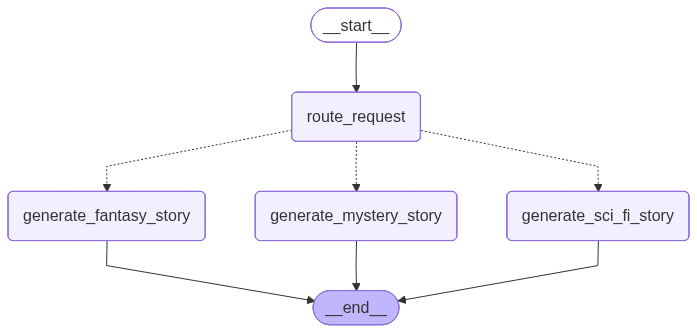

In [61]:

from IPython.display import Image, display

try:
    display(Image(conditional_workflow.get_graph().draw_mermaid_png()))
except Exception as e:

    print(e)

In [62]:
input = "write a fantasy story about a dragon"
state = {"input": input}
# conditional_workflow = build_workflow()
result = conditional_workflow.invoke(state)

Router response: the sky was painted in hues of purple and gold as the sun dipped below the horizon of the enchanted kingdom of eldoria. high above the rolling hills and glimmering lakes, a magnificent dragon named zephyros soared gracefully, his emerald scales glistening in the fading light. with wings that could eclipse the sun and eyes like molten gold, he was both feared and revered by the inhabitants of the land.

in eldoria, dragons were not mere beasts; they were ancient beings of wisdom and power, protectors of magical secrets. zephyros served as the guardian of the crystal cave, a mystical cavern filled with shimmering stones that held the very essence of magic. many sought to claim the crystals for themselves, but none had succeeded in breaching zephyros' watchful gaze.

one day, a fearless young woman named elara ventured into the whispering woods that bordered the dragon's domain. with her heart set on uncovering the true magic of the crystals, she had spent years gathering

ValidationError: 1 validation error for Route
step
  Input should be 'fantasy', 'sci-fi' or 'mystery' [type=literal_error, input_value='the sky was painted in h...ight for what is right.', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/literal_error